In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('placement 1.csv')

In [5]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package(in lpa)')

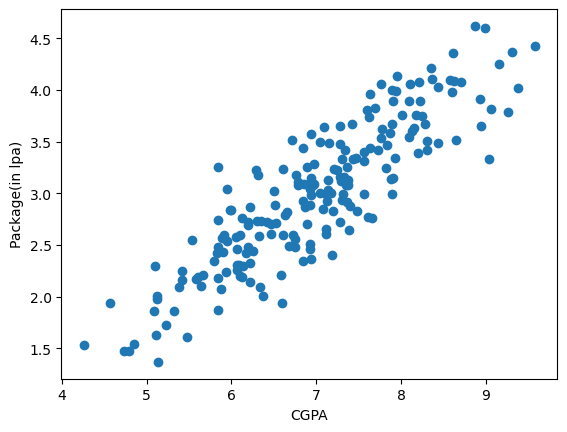

In [6]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [7]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

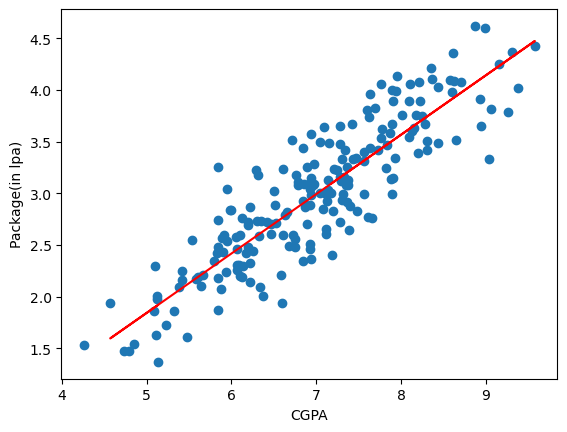

In [11]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
y_pred = lr.predict(X_test)

In [16]:
y_test.values

array([2.79, 3.23, 3.26, 3.04, 3.34, 4.21, 2.94, 2.87, 2.99, 3.58, 1.63,
       2.08, 4.08, 2.21, 3.47, 3.64, 2.74, 3.08, 2.17, 2.99, 2.31, 2.35,
       3.4 , 3.08, 3.81, 2.19, 1.53, 2.89, 3.16, 2.48, 3.51, 2.98, 3.39,
       3.28, 2.73, 3.74, 2.6 , 3.13, 3.82, 3.15])

In [ ]:
print("MAE",mean_absolute_error(y_test,y_pred)) #lpa

MAE 0.23150985393278373


In [18]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.08417638361329657


In [ ]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred))) # lpa

RMSE 0.2901316659954521


In [ ]:
print("MSE",r2_score(y_test,y_pred)) #cgpa can explain 77.30% variance in package
r2 = r2_score(y_test,y_pred)

MSE 0.7730984312051673


In [22]:
#Adjusted R2 Score
X_test.shape

(40, 1)

In [23]:
1 - (1 - r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7671273372895138

In [24]:
#We introduce one random column to check the effect on R2 and Adjusted R2
from hmac import new


new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)

new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.304527,3.26
1,5.12,0.849717,1.98
2,7.82,0.191134,3.25
3,7.42,0.487437,3.67
4,6.94,0.760694,3.57


Text(0, 0.5, 'Package(in lpa)')

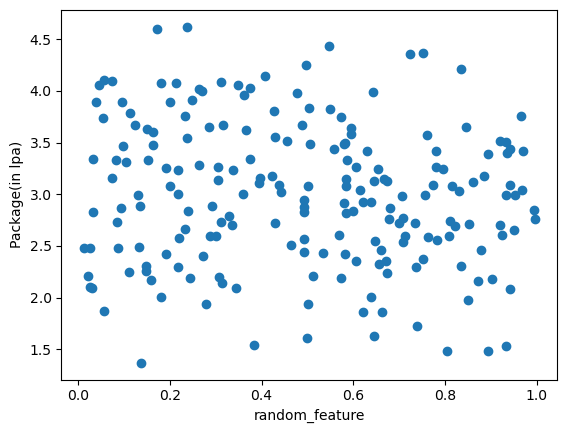

In [25]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [26]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [28]:
lr = LinearRegression()

In [29]:
lr.fit(X_train,y_train)

LinearRegression()

In [30]:
y_pred = lr.predict(X_test)

In [31]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7810625933637321


In [ ]:
1 - (1 - r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1) #0.7671273372895138

0.7692281389509609

In [33]:
#Adding a table 
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [34]:
new_df2.sample(5)

,cgpa,iq,package
124,6.06,1.11,2.31
108,7.76,3.14,3.54
45,7.87,3.68,3.58
50,9.58,4.93,4.43
139,7.19,3.10,2.40


Text(0, 0.5, 'Package(in lpa)')

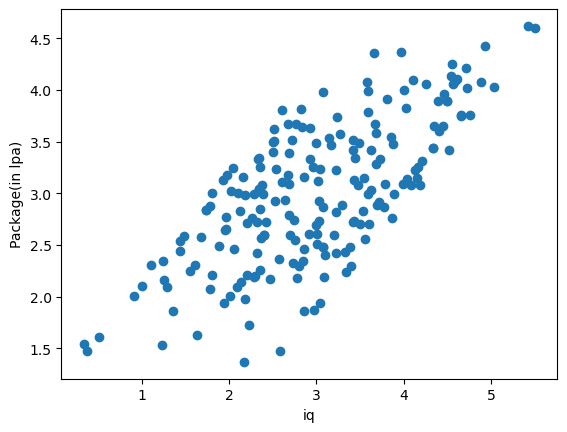

In [35]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [36]:
np.random.randint(-100,100)

-71

In [37]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [39]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

In [40]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8299168586757043


In [41]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8207231753608775